# 01 — Antigen & Epitope Data Exploration

**ITP Tolerogenic Epitope Design Toolkit — Phase 1**

This notebook is the first checkpoint of the data layer. We've built connectors
to UniProt (protein sequences) and IEDB (experimentally characterised epitopes).
Now we look at what those connectors actually return — sequence lengths, epitope
counts, peptide size distributions, and MHC allele coverage — to confirm the
data is sound before building the prediction engine on top of it.

In [2]:
import os
import sys
from pathlib import Path

# Add the project root to sys.path so `from src...` imports work,
# and set cwd to the project root so relative paths like "data/raw/"
# resolve correctly — regardless of where the kernel starts.
def _find_project_root() -> Path:
    """Walk up from cwd until we find a directory containing src/."""
    p = Path.cwd().resolve()
    for candidate in [p] + list(p.parents):
        if (candidate / "src").is_dir():
            return candidate
    return p

_root = _find_project_root()
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
os.chdir(_root)

import matplotlib.pyplot as plt
import pandas as pd

from src.data.antigens import ITP_ANTIGENS
from src.data.uniprot import fetch_all_itp_antigens
from src.data.iedb import fetch_all_itp_epitopes

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

---
## Section 1 — Antigen Sequences

The six ITP target proteins span two platelet surface complexes:

- **GPIIb/IIIa** (integrin αIIbβ3) — the primary autoantibody target in most ITP patients
- **GPIb-IX-V** — the von Willebrand factor receptor, a secondary target

We pull the full amino-acid sequences from UniProt and check their lengths.
Longer proteins yield more candidate epitope windows during peptide scanning,
so this gives us a first sense of how much search space each antigen contributes.

In [3]:
antigens = fetch_all_itp_antigens()

ag_df = pd.DataFrame(antigens)[["accession", "gene", "complex", "name", "sequence"]]
ag_df["length"] = ag_df["sequence"].str.len()

ag_df[["accession", "gene", "complex", "name", "length"]]

,accession,gene,complex,name,length
0,P08514,ITGA2B,GPIIb/IIIa,Integrin alpha-IIb,1039
1,P05106,ITGB3,GPIIb/IIIa,Integrin beta-3,788
2,P07359,GP1BA,GPIb-IX-V,Platelet glycoprotein Ib alpha chain,652
3,P13224,GP1BB,GPIb-IX-V,Platelet glycoprotein Ib beta chain,206
4,P14770,GP9,GPIb-IX-V,Platelet glycoprotein IX,177
5,P40197,GP5,GPIb-IX-V,Platelet glycoprotein V,560


In [4]:
print("Sequence previews (first 60 residues)\n")
for _, row in ag_df.iterrows():
    print(f"{row['gene']:<8} ({row['accession']})  {row['sequence'][:60]}...")

Sequence previews (first 60 residues)

ITGA2B   (P08514)  MARALCPLQALWLLEWVLLLLGPCAAPPAWALNLDPVQLTFYAGPNGSQFGFSLDFHKDS...
ITGB3    (P05106)  MRARPRPRPLWATVLALGALAGVGVGGPNICTTRGVSSCQQCLAVSPMCAWCSDEALPLG...
GP1BA    (P07359)  MPLLLLLLLLPSPLHPHPICEVSKVASHLEVNCDKRNLTALPPDLPKDTTILHLSENLLY...
GP1BB    (P13224)  MGSGPRGALSLLLLLLAPPSRPAAGCPAPCSCAGTLVDCGRRGLTWASLPTAFPVDTTEL...
GP9      (P14770)  MPAWGALFLLWATAEATKDCPSPCTCRALETMGLWVDCRGHGLTALPALPARTRHLLLAN...
GP5      (P40197)  MLRGTLLCAVLGLLRAQPFPCPPACKCVFRDAAQCSGGDVARISALGLPTNLTHILLFGM...


---
## Section 2 — Epitope Counts (All Records)

IEDB stores experimentally characterised epitopes — peptide fragments that have
been shown to interact with immune cells or antibodies in published assays.
We retrieve every human-host record mapped to our six antigens, without any
disease filter, to see the total available benchmark data.

Two numbers matter per antigen:
- **T-cell epitopes** — peptides presented by MHC molecules to T cells (our pipeline's primary focus)
- **B-cell epitopes** — regions recognised by antibodies (relevant for understanding autoantibody targets)

We also count how many records have an actual peptide sequence (vs. discontinuous
or undefined epitopes), since only sequence-defined epitopes can be used as
prediction benchmarks.

In [5]:
epi_all = fetch_all_itp_epitopes()
epi_all_df = pd.DataFrame(epi_all)

summary_all = (
    epi_all_df
    .assign(has_sequence=epi_all_df["epitope_sequence"].notna())
    .groupby(["uniprot_id", "epitope_type"])
    .agg(count=("epitope_sequence", "size"), with_sequence=("has_sequence", "sum"))
    .reset_index()
)

# Pivot for a cleaner view: one row per antigen
pivot_all = summary_all.pivot_table(
    index="uniprot_id",
    columns="epitope_type",
    values=["count", "with_sequence"],
    fill_value=0,
).astype(int)

# Flatten multi-level columns
pivot_all.columns = [f"{val}_{typ.replace('-','').lower()}" for val, typ in pivot_all.columns]

# Add gene names for readability
pivot_all["gene"] = pivot_all.index.map(lambda x: ITP_ANTIGENS[x]["gene"] if x in ITP_ANTIGENS else x)
cols = ["gene"] + [c for c in pivot_all.columns if c != "gene"]
pivot_all = pivot_all[cols]

# Add antigens with zero epitopes that got dropped by the groupby
for acc, meta in ITP_ANTIGENS.items():
    if acc not in pivot_all.index:
        pivot_all.loc[acc] = [meta["gene"], 0, 0, 0, 0]

pivot_all = pivot_all.sort_index()
pivot_all

,gene,count_bcell,count_tcell,with_sequence_bcell,with_sequence_tcell
uniprot_id,,,,,
P05106,ITGB3,44,312,37,312
P07359,GP1BA,108,0,106,0
P08514,ITGA2B,36,3,30,3
P13224,GP1BB,0,0,0,0
P14770,GP9,1,0,0,0
P40197,GP5,0,0,0,0


In [6]:
print(f"Total epitope records: {len(epi_all_df)}")
print(f"  T-cell: {(epi_all_df['epitope_type'] == 'T-cell').sum()}")
print(f"  B-cell: {(epi_all_df['epitope_type'] == 'B-cell').sum()}")
print(f"  With sequence: {epi_all_df['epitope_sequence'].notna().sum()}")

Total epitope records: 504
  T-cell: 315
  B-cell: 189
  With sequence: 488


---
## Section 3 — ITP-Specific Filtering

Not all epitope records in IEDB are from ITP studies. Many come from transplant
allo-reactivity research, healthy donor screens, or other autoimmune contexts.
For our benchmarking, we want to isolate the records that are explicitly
annotated with ITP as the disease.

We use `disease_filter="thrombocytopenic purpura"` to match records annotated
as *autoimmune thrombocytopenic purpura* in IEDB. This gives us the subset of
epitopes that were discovered in actual ITP patient studies — our ground truth
for benchmarking the prediction engine later.

In [7]:
epi_itp = fetch_all_itp_epitopes(disease_filter="thrombocytopenic purpura")
epi_itp_df = pd.DataFrame(epi_itp)

dropped = len(epi_all_df) - len(epi_itp_df)
print(f"Before filter: {len(epi_all_df)} records")
print(f"After filter:  {len(epi_itp_df)} records")
print(f"Dropped:       {dropped} records ({dropped / len(epi_all_df) * 100:.0f}%)")

Before filter: 504 records
After filter:  171 records
Dropped:       333 records (66%)


In [9]:
summary_itp = (
    epi_itp_df
    .assign(has_sequence=epi_itp_df["epitope_sequence"].notna())
    .groupby(["uniprot_id", "epitope_type"])
    .agg(count=("epitope_sequence", "size"), with_sequence=("has_sequence", "sum"))
    .reset_index()
)

pivot_itp = summary_itp.pivot_table(
    index="uniprot_id",
    columns="epitope_type",
    values=["count", "with_sequence"],
    fill_value=0,
).astype(int)

pivot_itp.columns = [f"{val}_{typ.replace('-','').lower()}" for val, typ in pivot_itp.columns]

pivot_itp["gene"] = pivot_itp.index.map(lambda x: ITP_ANTIGENS[x]["gene"] if x in ITP_ANTIGENS else x)
cols = ["gene"] + [c for c in pivot_itp.columns if c != "gene"]
pivot_itp = pivot_itp[cols]

for acc, meta in ITP_ANTIGENS.items():
    if acc not in pivot_itp.index:
        pivot_itp.loc[acc] = [meta["gene"], 0, 0, 0, 0]

pivot_itp = pivot_itp.sort_index()
pivot_itp

,gene,count_bcell,count_tcell,with_sequence_bcell,with_sequence_tcell
uniprot_id,,,,,
P05106,ITGB3,10,88,10,88
P07359,GP1BA,46,0,46,0
P08514,ITGA2B,26,1,22,1
P13224,GP1BB,0,0,0,0
P14770,GP9,0,0,0,0
P40197,GP5,0,0,0,0


---
## Section 4 — Epitope Sequence Length Distribution

MHC Class II molecules bind peptides roughly 9–25 amino acids long. The actual
binding core is ~9 residues, but the open-ended groove of MHC-II allows flanking
residues to extend beyond the groove. Most experimentally characterised epitopes
fall in the 12–20 residue range.

This histogram shows the length distribution of the ITP-filtered epitope
sequences. The vertical lines mark:
- **9 aa** — minimum MHC-II binding core
- **15 aa** — the standard window size for MHC-II prediction tools like NetMHCIIpan
- **25 aa** — the upper end of typical MHC-II presented peptides

If most of our benchmark epitopes fall within this range, that's a good sign
that our prediction engine's sliding window approach will cover them.

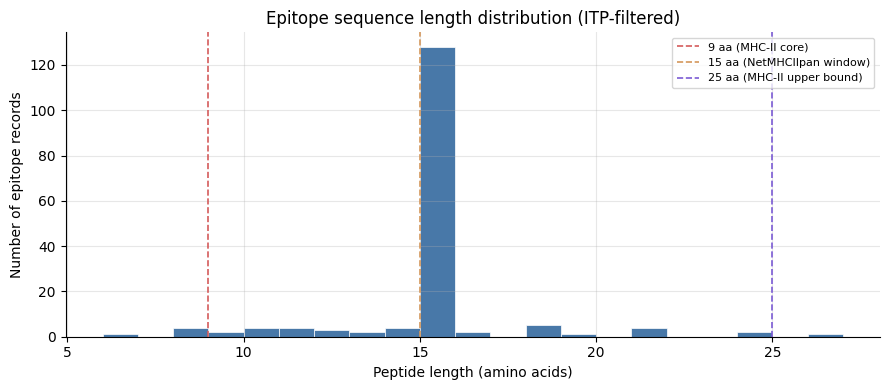


Sequences plotted: 167
  Min: 6 aa
  Max: 26 aa
  Median: 15 aa
  Within 9–25 aa range: 161/167 (96%)


In [10]:
seq_lengths = (
    epi_itp_df
    .loc[epi_itp_df["epitope_sequence"].notna(), "epitope_sequence"]
    .str.len()
)

fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(seq_lengths, bins=range(int(seq_lengths.min()), int(seq_lengths.max()) + 2),
        color="#4878A8", edgecolor="white", linewidth=0.5)

for pos, label, color in [
    (9, "9 aa (MHC-II core)", "#D45B5B"),
    (15, "15 aa (NetMHCIIpan window)", "#D4975B"),
    (25, "25 aa (MHC-II upper bound)", "#7B5BD4"),
]:
    ax.axvline(pos, color=color, linestyle="--", linewidth=1.2, label=label)

ax.set_xlabel("Peptide length (amino acids)")
ax.set_ylabel("Number of epitope records")
ax.set_title("Epitope sequence length distribution (ITP-filtered)")
ax.legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.show()

print(f"\nSequences plotted: {len(seq_lengths)}")
print(f"  Min: {seq_lengths.min()} aa")
print(f"  Max: {seq_lengths.max()} aa")
print(f"  Median: {seq_lengths.median():.0f} aa")
within = ((seq_lengths >= 9) & (seq_lengths <= 25)).sum()
print(f"  Within 9–25 aa range: {within}/{len(seq_lengths)} ({within / len(seq_lengths) * 100:.0f}%)")

---
## Section 5 — MHC Allele Landscape

For the tolerogenic scoring pipeline to work, we need to know which MHC alleles
present ITP epitopes. Each HLA allele has a differently-shaped binding groove,
so the same protein produces different epitopes in different patients.

IEDB records sometimes specify the exact allele (e.g. `HLA-DRB1*04:05`),
sometimes just the locus (`HLA-DR`), and sometimes only `human` (meaning the
restriction was not characterised). This chart shows the distribution — a
predominance of `human` or class-level annotations means we'll be relying
heavily on *predicted* MHC binding rather than experimentally confirmed
restrictions, which is exactly what the Phase 2 prediction engine is for.

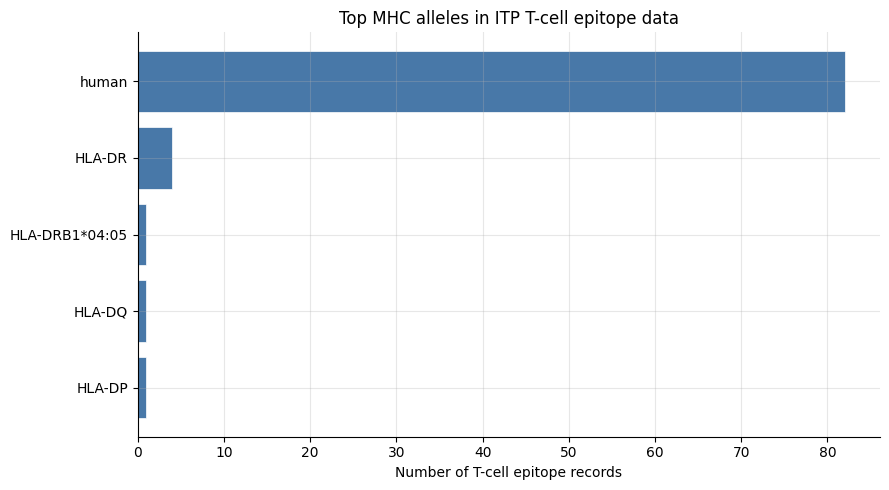


ITP T-cell records: 89
  With MHC annotation: 89
  Unresolved ('human' or 'not defined'): 82
  With specific allele: 7


In [11]:
tcell_itp = epi_itp_df[epi_itp_df["epitope_type"] == "T-cell"].copy()

allele_counts = (
    tcell_itp
    .loc[tcell_itp["mhc_allele"].notna(), "mhc_allele"]
    .value_counts()
    .head(15)
)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    allele_counts.index[::-1],
    allele_counts.values[::-1],
    color="#4878A8",
    edgecolor="white",
    linewidth=0.5,
)

ax.set_xlabel("Number of T-cell epitope records")
ax.set_title("Top MHC alleles in ITP T-cell epitope data")

plt.tight_layout()
plt.show()

total_tcell = len(tcell_itp)
with_allele = tcell_itp["mhc_allele"].notna().sum()
unresolved = tcell_itp["mhc_allele"].isin(["human", "not defined"]).sum()

print(f"\nITP T-cell records: {total_tcell}")
print(f"  With MHC annotation: {with_allele}")
print(f"  Unresolved ('human' or 'not defined'): {unresolved}")
print(f"  With specific allele: {with_allele - unresolved}")

---
## Summary

**What we have:**
- Six antigen sequences covering both ITP-relevant platelet complexes  
- A benchmark set of ITP-specific epitopes, dominated by GPIIIa (P05106) — consistent with the literature identifying GPIIb/IIIa as the primary autoantibody target  
- Most epitope sequences fall within the 9–25 aa MHC-II binding range  

**What this tells us about Phase 2:**
- The MHC allele annotations are overwhelmingly unresolved — nearly all T-cell records just say `human` rather than specifying an HLA allele. This confirms that *computational* MHC binding prediction (NetMHCIIpan) is essential. We can't rely on experimental allele assignments alone.  
- GPIIIa (ITGB3 / P05106) has by far the richest epitope data. It will be our primary benchmark target when evaluating prediction accuracy.  
- ITGA2B has zero usable T-cell benchmark epitopes after ITP filtering — the single surviving record corresponds to a discontinuous epitope with no linear sequence. As a result, Phase 2 T-cell prediction benchmarking will focus exclusively on ITGB3.  
- Several antigens (GP1BB, GP5) have zero IEDB records. Predictions for these will be entirely computational — no experimental validation data available yet.  